In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

In [2]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['font.size'] = 15
mpl.rcParams['errorbar.capsize'] = 3
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.axisbelow'] = True

In [3]:
cent_dict = {25 : 1, 26 : 2, 27 : 3, 28 : 4, 29 : 5, 30 : 6, 31 : 7, 32 : 8,
    57 : 16, 58 : 15, 59 : 14, 60 : 13, 61 : 12, 62 : 11, 63 : 10, 64 : 9}

valid_pairs = [[1,9], [2,10], [3,11], [4,12], [5,13], [6,14], [7,15], [8,16]]

In [4]:
def read_df(path):
    df = pd.read_csv(path,delimiter=',',dtype=str,header=None,
                     names=['clock_RB','hex','clock_FPGA','ang','count'])
    df['bin'] = df['hex'].apply(lambda x: bin(int(x, 16))[2:].zfill(len(x)*4))
    df['dets'] = df.bin.apply(lambda b: [i+1 for i, bit in enumerate(b) if bit == '1'])
    for i in range(len(df.dets)):
        for j in range(len(df.dets[i])):
            df.dets[i][j] = cent_dict[df.dets[i][j]]
    df_new = pd.DataFrame({'t':df['clock_FPGA'].astype(int),'ang':df['ang'].astype(int),
                           'counts':df['count'].astype(int),'dets':df['dets']})
    return df_new

def correct_clock(df):
    drops = []
    check = True
    while check:
        for i in range(1,len(df)):
            if df.t.iloc[i] <= df.t[i-1]:
                drops.append(i)
        print(len(drops)/len(df))
        df = df.copy().drop(drops).reset_index(drop=True)
        drops = []
        for i in range(1,len(df)):
            if df.t.iloc[i] <= df.t[i-1]:
                drops.append(i)
        if len(drops) == 0:
            check = False
    return df

lower_ang = 161.5
upper_ang = 5335
def filtrar_ang(df,lower_ang,upper_ang):
    drops = []
    delta = upper_ang-lower_ang
    for i in range(len(df)):
        if df.ang.iloc[i] < lower_ang or df.ang.iloc[i] > upper_ang:
            drops.append(i)
    print(len(drops)/len(df))
    df = df.copy().drop(drops).reset_index(drop=True)
    df['ang'] = (df.ang-lower_ang)*360/delta
    
    return df

def filtrar_coincidencias(df,valid_pairs):
    df = df[df.dets.isin(valid_pairs)]
    df = df.reset_index(drop=True)
    return df

# esto nos deja un df con la información que nos importa, el tiempo (para chequear cuestiones del flujo), el ángulo,
# el contador y los centelladores por los que pasó (ya traducido a nuestra numeración)

In [29]:
df1 = read_df('MEDICIONES/Arriba/2025_11_16_06h00_muontumbler-m101.txt')
for day in [17,18,19]:
    df_new = read_df(f'MEDICIONES/Arriba/2025_11_{day}_06h00_muontumbler-m101.txt')
    df1 = pd.concat([df1,df_new]).reset_index(drop=True)

df1 = correct_clock(df1)
df1 = filtrar_ang(df1,lower_ang,upper_ang)

#df2 = read_df('MEDICIONES/umbral up pt2/11/2025_11_09_06h00_muontumbler-m101.txt')
#for day in [10,11,12,13,14,15,16]:
#    df_new = read_df(f'MEDICIONES/umbral up pt2/11/2025_11_{day}_06h00_muontumbler-m101.txt')
#    df2 = pd.concat([df2,df_new]).reset_index(drop=True)

#df2 = correct_clock(df2)
#df2 = filtrar_ang(df2,lower_ang,upper_ang)
df = df1.copy()
df = df[df.t < 3350*1e7*60]
#df = pd.concat([df1,df2])
filtered_df = filtrar_coincidencias(df,valid_pairs)
filtered_df

0.008449822658042979
0.0003366649132035771
0.001957194267314856


,t,ang,counts,dets
0,2252969933,139.762250,582,"[2, 10]"
1,2524176617,96.340968,586,"[2, 10]"
2,2859805805,160.359524,595,"[2, 10]"
3,3038266040,143.171934,598,"[2, 10]"
4,4357581340,95.784285,610,"[2, 10]"
...,...,...,...,...
3092,2006906487958,301.339519,768,"[2, 10]"
3093,2007170135235,301.478689,774,"[2, 10]"
3094,2007281989383,301.409104,777,"[2, 10]"
3095,2008753874889,301.687446,807,"[1, 9]"


In [ ]:
plt.hist(df.ang,bins=51,color='navy')
plt.xlabel('Ángulo [u.a.]')
plt.ylabel('Cantidad de eventos [u.a.]')
plt.tight_layout()
#plt.savefig('plots/angulos todos.png')
#plt.hist(df.ang,bins=50,color='crimson',alpha=0.5)
plt.show()
#plt.savefig('plots/angulos todos superpuestos.png')
#plt.xlim(0,200)
#plt.xlim(5200,5500)
#plt.axvline(159.88,ls='--',color='crimson')
#plt.axvline(5335,ls='--',color='crimson')
#plt.savefig('plots/modulación umbralup.png')

8.666666666666664


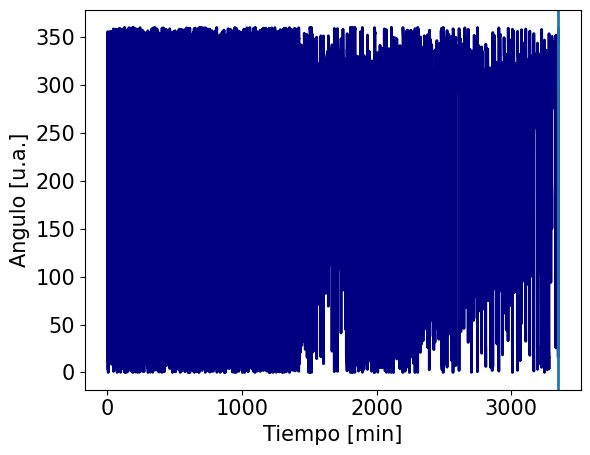

In [23]:
plt.plot(df.t*1e-7/60,df.ang,color='navy')
plt.xlabel('Tiempo [min]')
plt.ylabel('Angulo [u.a.]')
plt.tight_layout()
#plt.ylim(0,200)
lower_ang = 161.5
#plt.axhline(lower_ang,ls='--',color='crimson')
#plt.show()
#plt.plot(df.t*1e-7/60,df.ang,color='navy')
plt.xlabel('Tiempo [min]')
plt.ylabel('Angulo [u.a.]')
plt.tight_layout()
#plt.ylim(5200,5400)
upper_ang = 5335
#plt.axhline(upper_ang,ls='--',color='crimson')
plt.axvline(3350)
print(3400/60-48)

In [26]:
my_list = []
for a in np.array(df.dets):
    if len(a) == 2:
        my_list.append(a[0])
print(np.unique(my_list))
my_list = []
for a in np.array(df.dets):
    if len(a) == 2:
        my_list.append(a[1])
print(np.unique(my_list))
# si está todo en orden deberian ser todos los números del 1 al 8 y del 9 al 16

[1 2 3 4 5 6 7 8]
[ 9 10 11 12 13 14 15 16]


[11351.  7676.  2099.   590.  6854.  6788.  1843. 11881. 11689.  7818.
  7578.  7844.  1147.   198.  1519. 10715.]


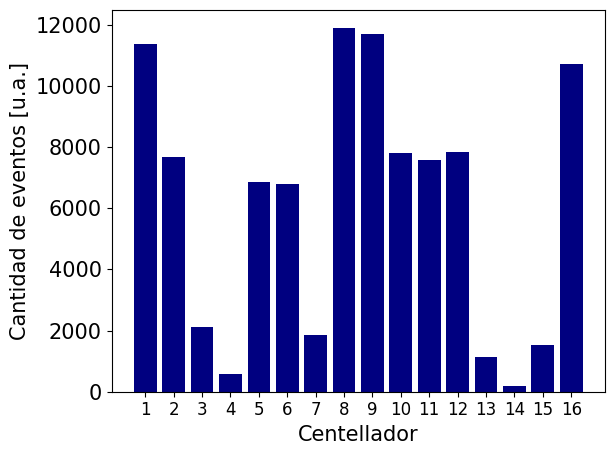

In [10]:
x,y = np.unique(df.dets,return_counts=True)
#print(x)
cents = np.arange(1,17)
cent_counts = np.zeros(16)
for cent in cents:
    for i in range(len(y)):
        if cent in x[i]:
            cent_counts[cent-1] += y[i]

plt.bar(cents,cent_counts,color='navy')
plt.xticks(ticks=cents,fontsize=12)
plt.xlabel('Centellador')
plt.ylabel('Cantidad de eventos [u.a.]',fontsize=15)
plt.tight_layout()
print(cent_counts)
#plt.savefig('plots/solos umbral up.png')

[list([1, 9]) list([2, 10]) list([3, 11]) list([4, 12]) list([5, 13])
 list([6, 14]) list([7, 15]) list([8, 16])] [734 870 240  71  74  15 160 933]


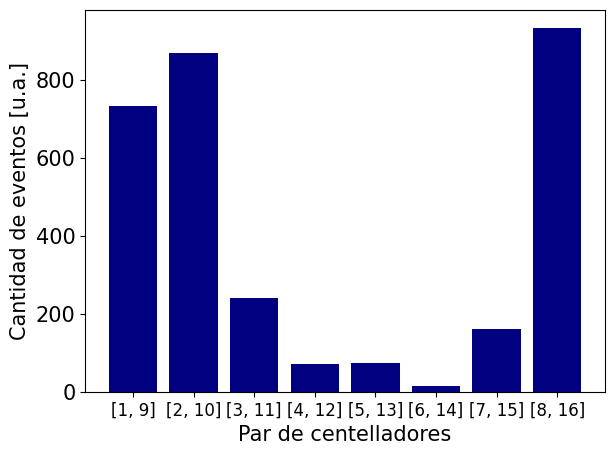

In [27]:
x,y = np.unique(filtered_df.dets,return_counts=True)
plt.bar(np.arange(len(y)),y,color='navy')
locs,labels = plt.xticks()
plt.xticks(ticks=np.arange(len(y)),labels=x,fontsize=12)
plt.xlabel('Par de centelladores')
plt.ylabel('Cantidad de eventos [u.a.]',fontsize=15)
plt.tight_layout()
#plt.savefig('plots/pares umbral up 2.png')
print(x,y)

In [12]:
fases_set = False
fases = []

In [6]:
bin_width = 9.619727799698852*2

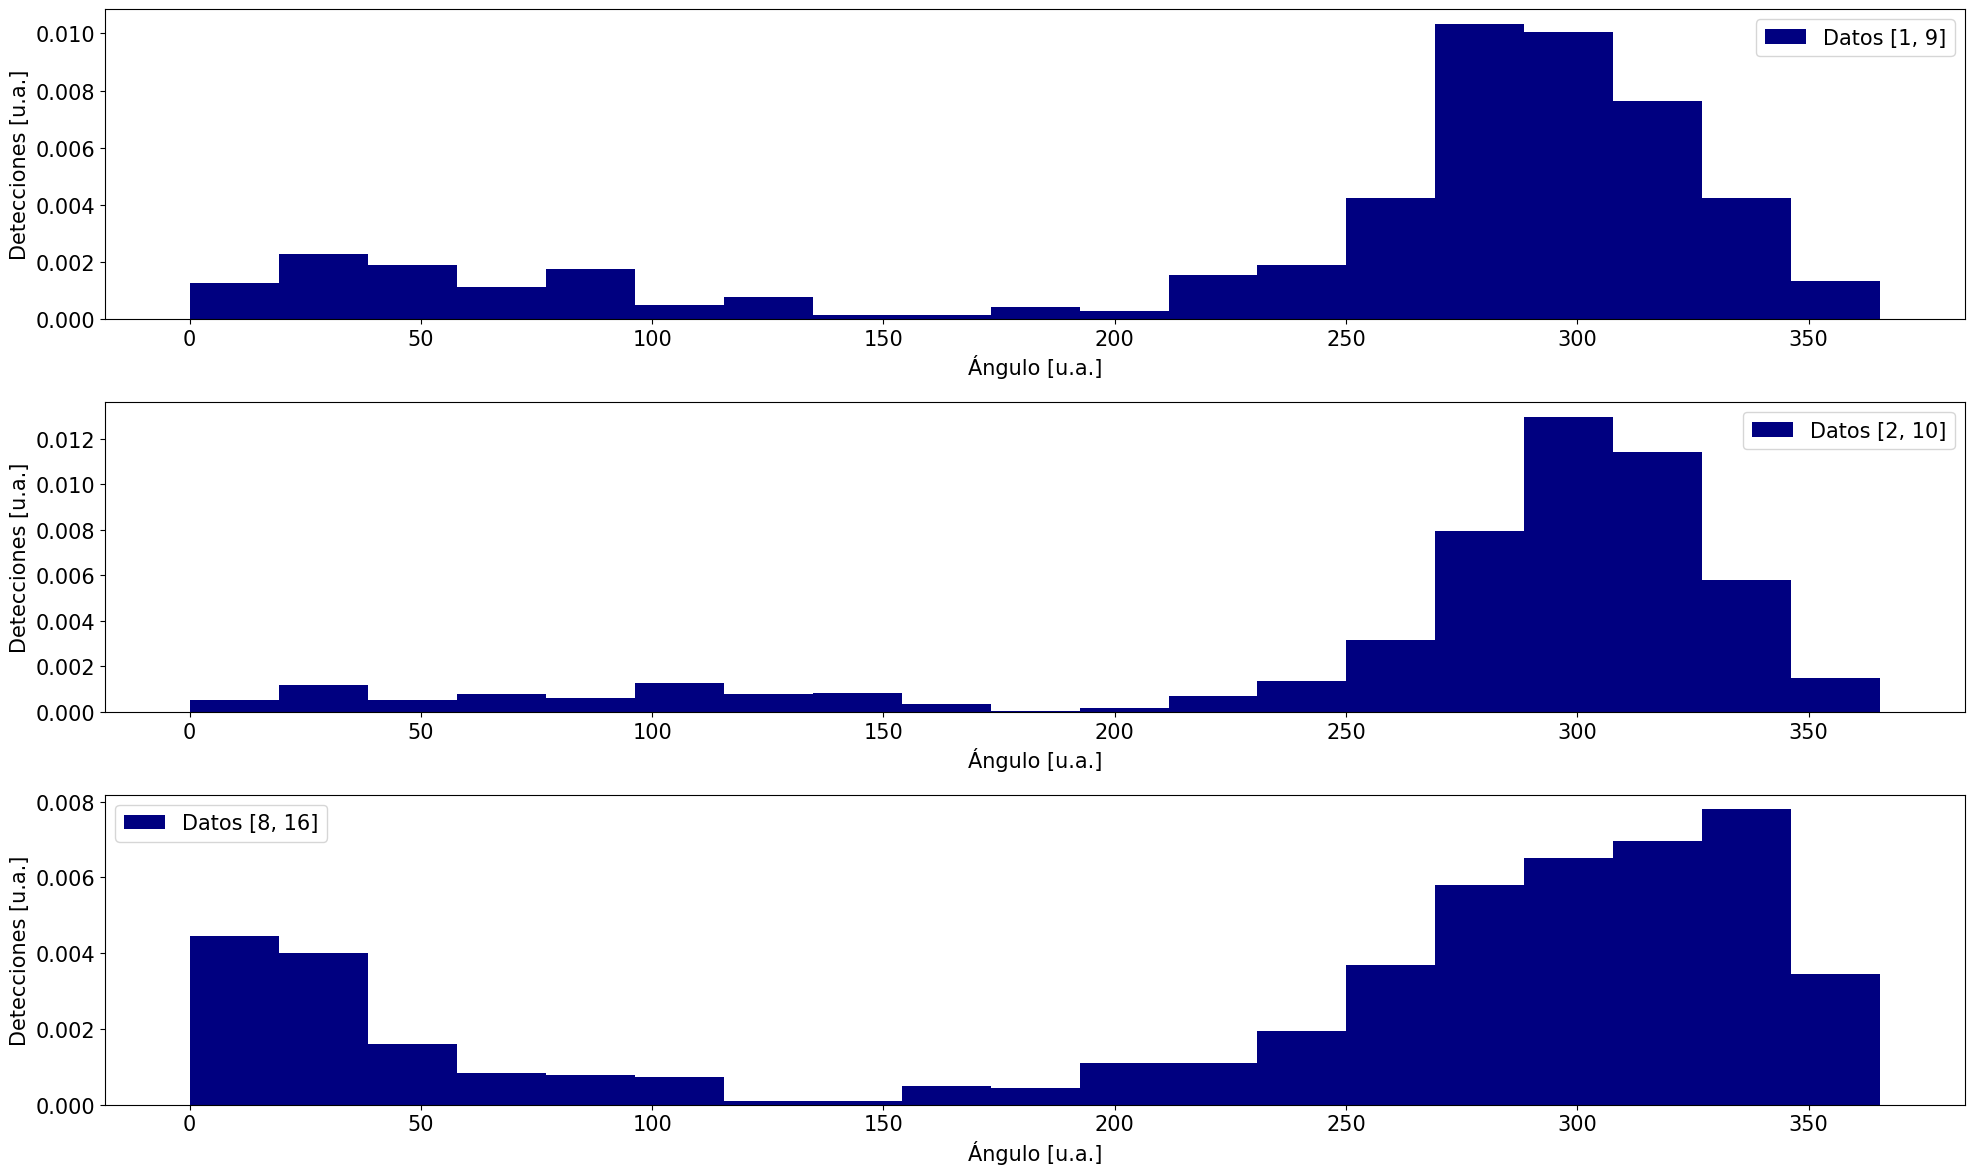

In [30]:
from scipy.optimize import curve_fit as cf
from scipy.stats import kstest

cos2_cdf = lambda x : (np.radians(x) + np.cos(np.radians(x))*np.sin(np.radians(x)))/(2*np.pi/4)

fig,axs = plt.subplots(3,1,figsize=(20,12),layout='tight')
axs = axs.flatten()
my_pairs = [[1,9],[2,10],[8,16]]
delta_cent = 18.7
ang0 = np.array([-3,-2,4])*delta_cent+3

func = lambda x,A,n,phi,C : A*np.abs(np.cos(np.radians(x+phi)))**n + C
func2 = lambda x,A,phi,C : A*np.abs(np.cos(np.radians(x+phi)))**2 + C
func3 = lambda x,A,phi,C : A*np.abs(np.cos(np.radians(x+phi)))**3 + C
func_teo = lambda x,A,phi,C : A*np.abs(np.cos(np.radians(x+phi)))**2.21 + C

offsets = []
amps = []

#if len(fases) > 0:
#    fases_set = True

#if not fases_set:
#    fases = []
for i in range(len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    #if fases_set:
    #    df_pair.ang = np.mod(df_pair.ang + fases[i],360)

    n,bins,_ = axs[i].hist(df_pair.ang,bins=np.arange(0,360+bin_width/2,bin_width),density=True,color='navy',label=f'Datos {pair}')

    x = bins[:-1] + np.diff(bins)/2
    y = n
#    pars,cov = cf(func_teo,x,y,p0=[np.max(n),60,np.min(n)])
    #pars,cov = cf(func,x,y,p0=[np.max(n),2,90,np.min(n)])
    #n_m = pars[1]
    #err_n_m = np.sqrt(cov[1,1])

    #x_adj = np.linspace(0,360,1000)
    #y_adj = func(x_adj,*pars)
    
    #axs[i].plot(x_adj,y_adj,color='crimson',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)} \n \u03d5 = {np.round(pars[2],1)}$')

#    pars,cov = cf(func3,x,y,p0=[np.max(n),60,np.min(n)])
#    y_adj = func3(x_adj,*pars)
#    axs[i].plot(x_adj,y_adj,color='forestgreen',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)}')
    
    axs[i].legend()
    axs[i].set_xlabel('Ángulo [u.a.]')
    axs[i].set_ylabel('Detecciones [u.a.]')
#    print(pars[2],np.sqrt(cov[2,2]))
    #phi = pars[2]
    #C = pars[3]
    #A = pars[0]
    #if not fases_set:
    #    fases.append(phi)
    #offsets.append(C)
    #amps.append(A)
    #cos2_offset_pdf = lambda x : 2*(1/360-C)*np.cos(np.radians(x+phi))**2+C
#    axs[i].plot(x_adj,cos2_offset_pdf(x_adj),color='forestgreen')
    #A = 2*(1/360-C)
    #cos2_offset = lambda x : x/360 + 45/np.pi*A*np.sin(np.pi*x/90)
    #print(f'p-valor de Kolmogorov {pair}: {kstest(np.mod(df_pair.ang+phi,360),cos2_offset).pvalue}')
plt.savefig('plots/luz.png')

In [60]:
print(offsets[0],amps[0])

0.005013532375344965 -0.004134347878070511


In [14]:
print(fases)
fases_teoricas = np.array([-3,-2,4])*18.7
print(fases_teoricas)
print(np.diff(fases),np.diff(fases_teoricas))

[np.float64(90.68545010922699), np.float64(70.58099609586121), np.float64(117.60357025402378)]
[-56.1 -37.4  74.8]
[-20.10445401  47.02257416] [ 18.7 112.2]


p-valor de Kolmogorov [8, 16]: 1.5134272676539746e-18


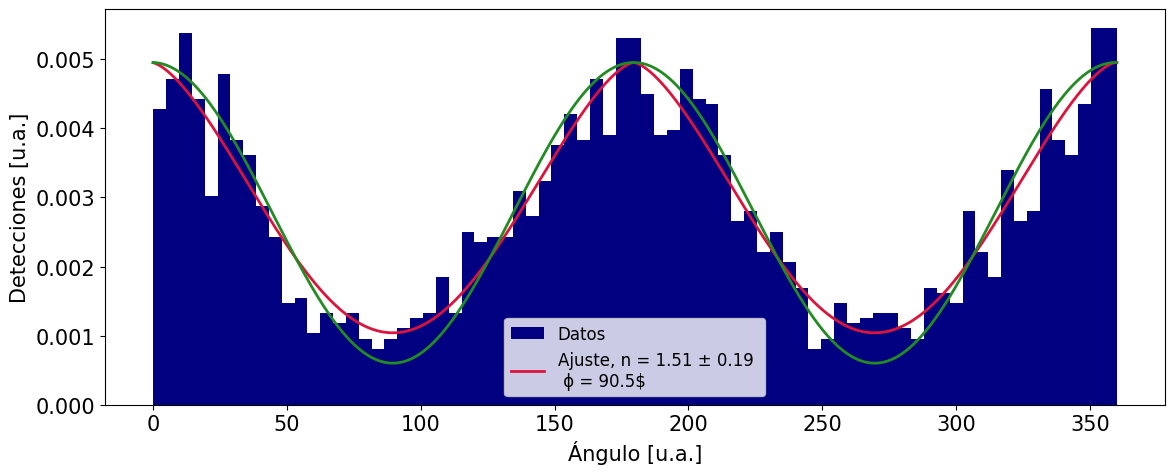

In [23]:
plt.figure(figsize=(12,5))
full_filtered_df = filtrar_coincidencias(filtered_df,[my_pairs[0]])
full_filtered_df.ang = np.mod(df_pair.ang + fases[0],360)
for i in range(1,len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    df_pair.ang = np.mod(df_pair.ang + fases[i],360)
    full_filtered_df = pd.concat([full_filtered_df,df_pair]).reset_index(drop=True)
bins = np.arange(0,360+bin_width/2,bin_width)
bins = 75
n,bins,_ = plt.hist(df_pair.ang,bins=bins,density=True,color='navy',label='Datos')
x = bins[:-1] + np.diff(bins)/2
y = n
pars,cov = cf(func,x,y,p0=[np.max(n),2,90,np.min(n)])
n_m = pars[1]
err_n_m = np.sqrt(cov[1,1])

x_adj = np.linspace(0,360,1000)
y_adj = func(x_adj,*pars)

plt.plot(x_adj,y_adj,color='crimson',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)} \n \u03d5 = {np.round(pars[2],1)}$')

plt.legend(fontsize=12)
plt.xlabel('Ángulo [u.a.]')
plt.ylabel('Detecciones [u.a.]')
phi = pars[2]
C = pars[3]
cos2_offset_pdf = lambda x : 2*(1/360-C)*np.cos(np.radians(x+phi))**2+C
plt.plot(x_adj,cos2_offset_pdf(x_adj),color='forestgreen')
A = 2*(1/360-C)
cos2_offset = lambda x : x/360 + 45/np.pi*A*np.sin(np.pi*x/90)
print(f'p-valor de Kolmogorov {pair}: {kstest(np.mod(full_filtered_df.ang+phi,360),cos2_offset).pvalue}')

In [63]:
from scipy.special import gamma
def sampling_teo(n,C,A,N_samples=10000,seed=0):
    A = np.abs(A)
    rng = np.random.default_rng(seed)
    samples = []
    filled = 0
    uniform_area = C*2*np.pi
    cos_area = 2*A*np.sqrt(np.pi)*gamma((n+1)/2)/gamma(n/2+1)
    total_area = uniform_area + cos_area
    p_uniform = uniform_area/cos_area

    while len(samples) < N_samples:
        size = N_samples-len(samples)
        sample_uniform = rng.random(size) < p_uniform
        size_uniform = np.sum(sample_uniform)
        if size_uniform > 0:
            samples_uniform = rng.uniform(0,360,size_uniform)
            samples.extend(samples_uniform)
        size_cos = size - size_uniform
        if size_cos > 0:
            samples_cos = []
            while len(samples_cos) < size_cos:
                size_cos_needed = (size_cos - len(samples_cos))*3
                first_sample_deg = rng.uniform(0,360,size_cos_needed)
                first_sample_rad = np.radians(first_sample_deg)
                u = rng.random(size_cos_needed)
                accept = u < np.abs(np.cos(first_sample_rad))**n
                samples_cos.extend(first_sample_deg[accept])
            samples.extend(samples_cos[:size_cos])
    return np.array(samples)

Text(0.5, 0, 'Ángulo [°]')

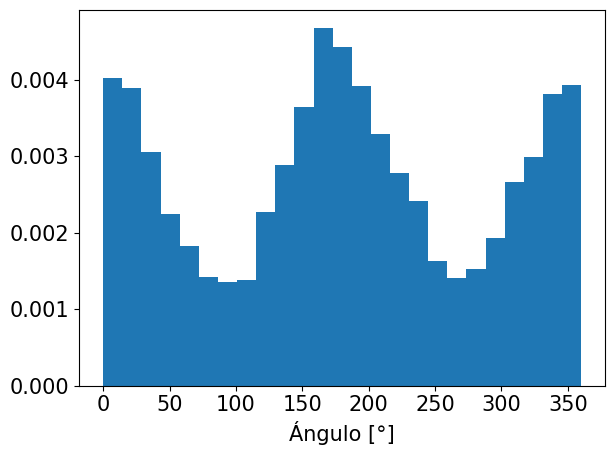

In [80]:
sample_teo = sampling_teo(2.21,0.001,0.004,N_samples=int(1e4))
plt.hist(sample_teo,bins=25,density=True)
plt.xlabel('Ángulo [°]')

0.0035756908641749125 2.755157468470067 -68.00720660067967 0.001207658672702375


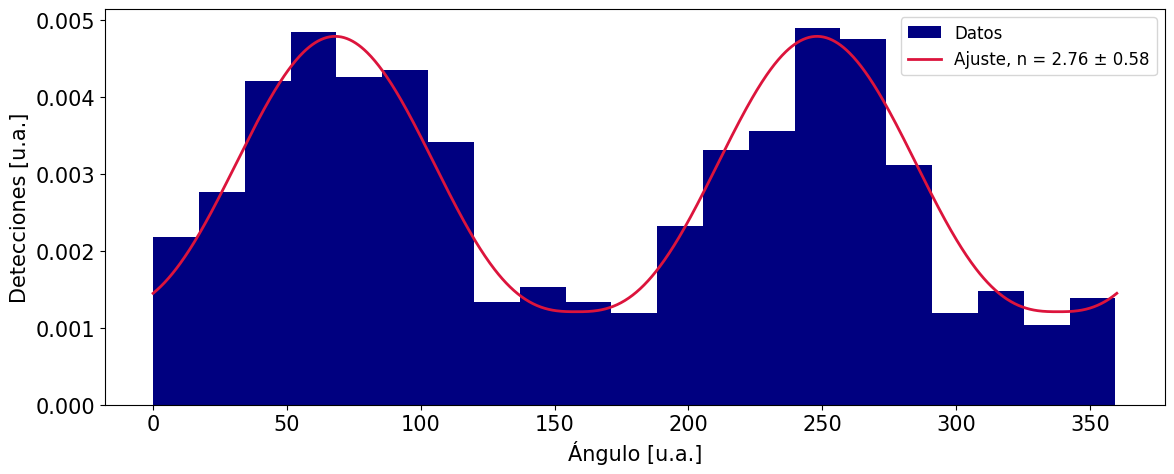

In [143]:
plt.figure(figsize=(12,5))
angulos = []
for i in range(len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    angs_corridos = np.mod(df_pair.ang - fases[i],360).to_list()
    angulos += angs_corridos

n,bins,_ = plt.hist(df_pair.ang,bins=21,density=True,color='navy',label=f'Datos')

x = bins[:-1] + np.diff(bins)/2
y = n
pars,cov = cf(func,x,y,p0=[np.max(n),2,60,np.min(n)])
n_m = pars[1]
err_n_m = np.sqrt(cov[1,1])

x_adj = np.linspace(0,360,1000)
y_adj = func(x_adj,*pars)
    
plt.plot(x_adj,y_adj,color='crimson',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)}')
plt.legend(fontsize=12)
plt.xlabel('Ángulo [u.a.]')
plt.ylabel('Detecciones [u.a.]')
print(*pars)

In [24]:
from scipy.signal import lombscargle
from scipy.signal import find_peaks as fp

[0.11582418] [8.63377609]


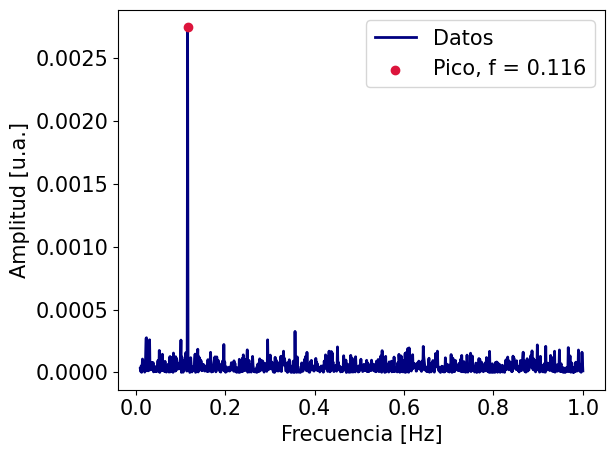

In [25]:
freqs = np.linspace(0.01,1,1002)*1e-7
powers = lombscargle(df.t,df.ang-np.mean(df.ang),freqs*2*np.pi,normalize=True)
pk_idxs,_ = fp(powers,height=0.001)
plt.plot(freqs*1e7,powers,color='navy',label='Datos',zorder=1)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [u.a.]')
f_pks = freqs[pk_idxs]*1e7
T_pks = 1/f_pks
print(f_pks,T_pks)
plt.scatter(freqs[pk_idxs]*1e7,powers[pk_idxs],color='crimson',label=f'Pico, f = {np.round(f_pks[0],3)}',zorder=2)
plt.legend()
plt.tight_layout()
#plt.savefig('plots/periodograma2.png')

[9.86424977]
42863
p-valor de Kolmogorov: 0.37974488320440314


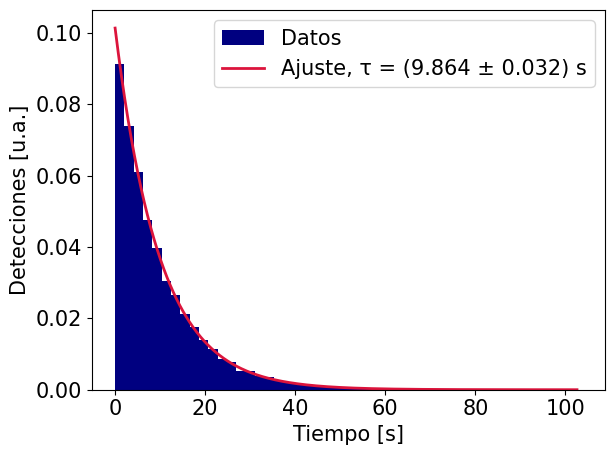

In [21]:
exp_d = lambda x,t : 1/t*np.exp(-x/t)

t_diffs = np.diff(df.t)*1e-7
n,bins,_ = plt.hist(t_diffs,bins=50,density=True,color='navy',label='Datos')
x_hist = bins[:-1] + np.diff(bins)/2
y_hist = n

pars,cov = cf(exp_d,x_hist,y_hist)
x_adj = np.linspace(0,np.max(x_hist),1000)
y_adj = exp_d(x_adj,*pars)
plt.plot(x_adj,y_adj,color='crimson',label=F'Ajuste, \u03C4 = ({np.round(pars[0],3)} \u00b1 {np.round(np.sqrt(cov[0,0]),3)}) s')
plt.legend()
plt.xlabel('Tiempo [s]')
plt.ylabel('Detecciones [u.a.]')
plt.tight_layout()
print(pars)
print(len(t_diffs))
exp_cdf = lambda x : 1 - np.exp(-x/pars[0])
print(f'p-valor de Kolmogorov: {kstest(t_diffs,exp_cdf).pvalue}')
#plt.savefig('t_inter.png')

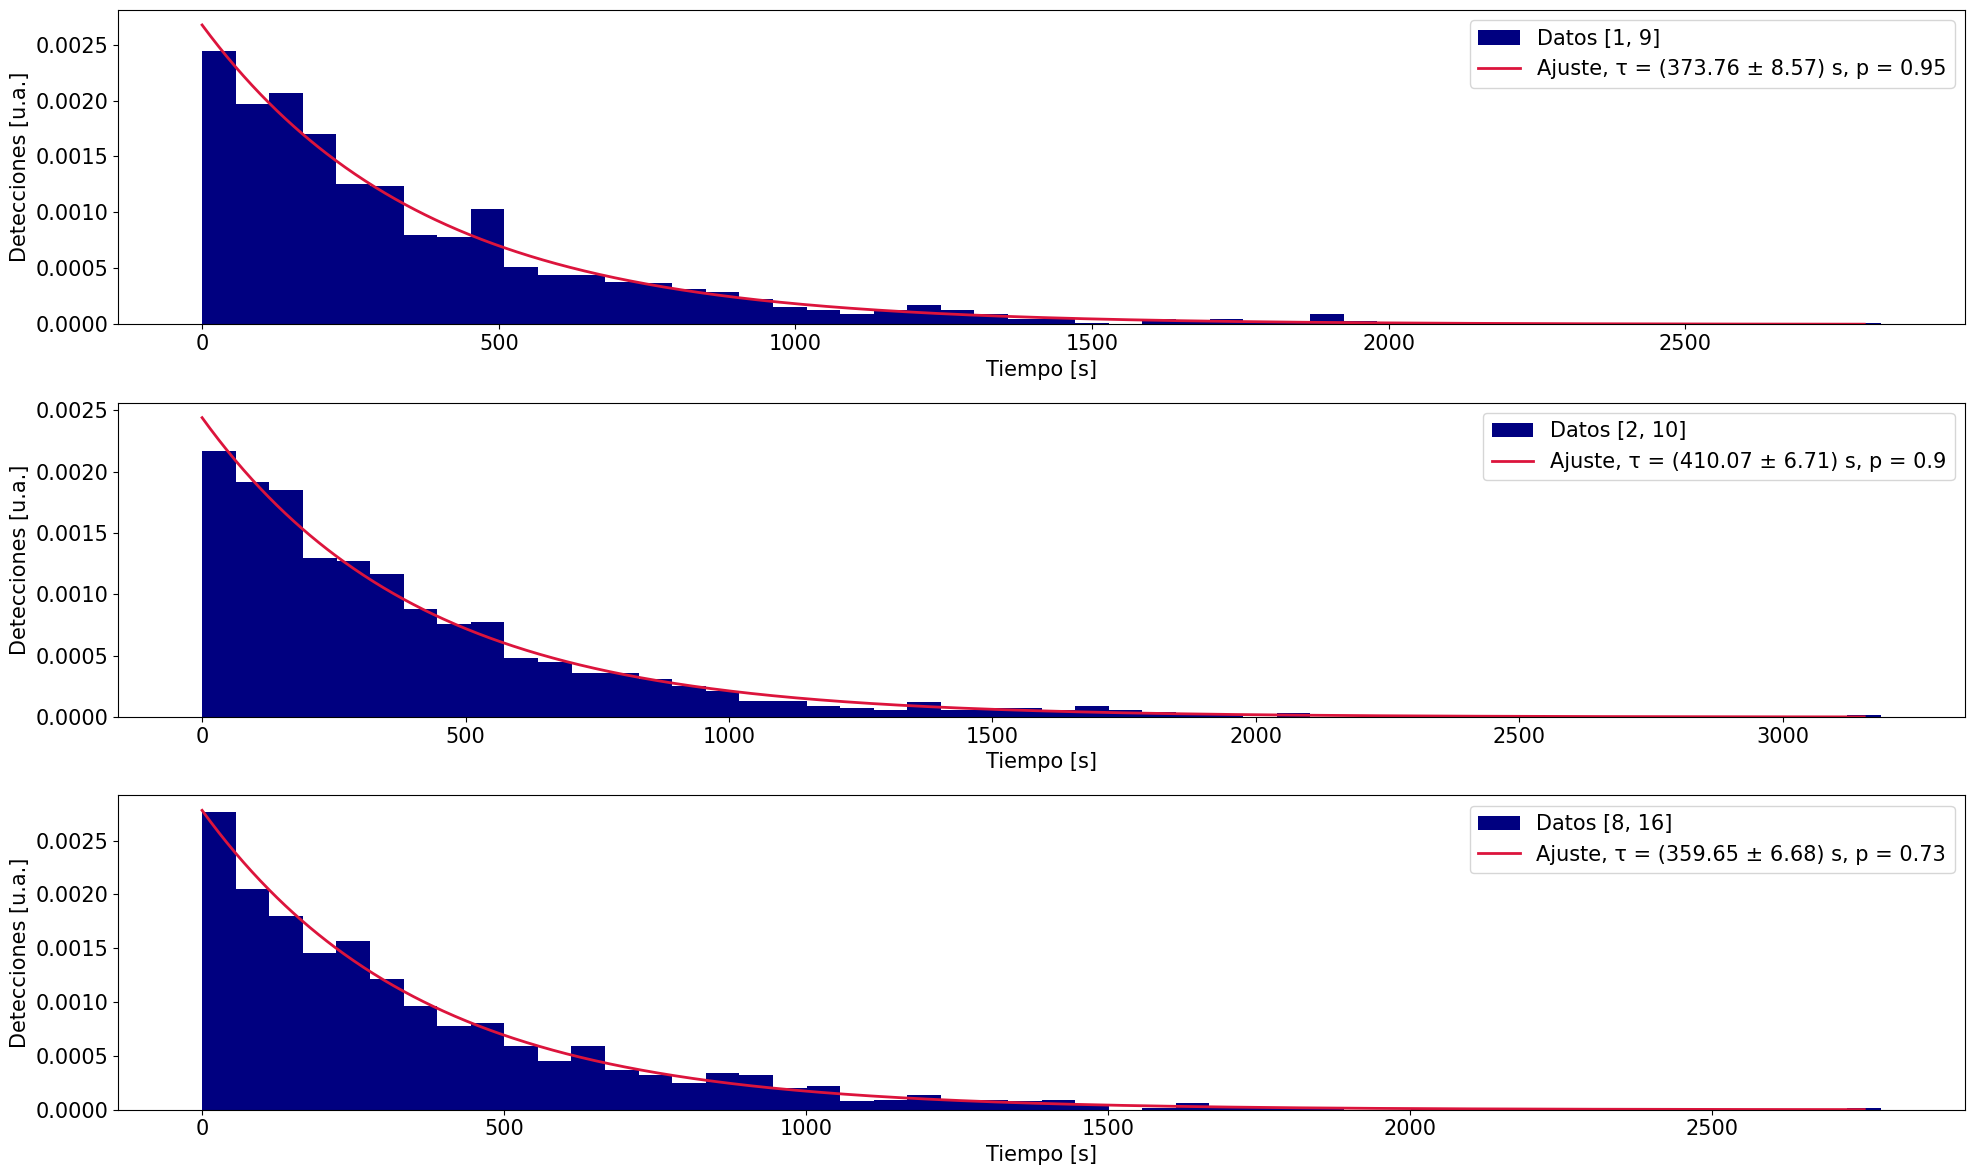

In [22]:
fig,axs = plt.subplots(3,1,figsize=(20,12),layout='tight')
axs = axs.flatten()
taus = []
err_taus = []
std_taus = []
for i in range(len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])

    t_diffs = np.diff(df_pair.t)*1e-7
    n,bins,_ = axs[i].hist(t_diffs,bins=50,density=True,color='navy',label=f'Datos {pair}')
    x_hist = bins[:-1] + np.diff(bins)/2
    y_hist = n
    
    pars,cov = cf(exp_d,x_hist,y_hist,p0=[np.mean(t_diffs)])
    taus.append(pars[0])
    err_taus.append(cov[0,0])
    std_taus.append(np.std(t_diffs))
    x_adj = np.linspace(0,np.max(x_hist),1000)
    y_adj = exp_d(x_adj,*pars)
    exp_cdf = lambda x : 1 - np.exp(-x/pars[0])
    pval_k = kstest(t_diffs,exp_cdf).pvalue
    axs[i].plot(x_adj,y_adj,color='crimson',label=F'Ajuste, \u03C4 = ({np.round(pars[0],2)} \u00b1 {np.round(np.sqrt(cov[0,0]),2)}) s, p = {np.round(pval_k,2)}')
    axs[i].legend()
    axs[i].set_xlabel('Tiempo [s]')
    axs[i].set_ylabel('Detecciones [u.a.]')
#plt.savefig('plots/muchas_exponenciales.png')

In [19]:
from scipy.optimize import curve_fit as cf
exp_d = lambda x,t : 1/t*np.exp(-x/t)
from scipy.stats import kstest

Text(0, 0.5, 'Detecciones [u.a.]')

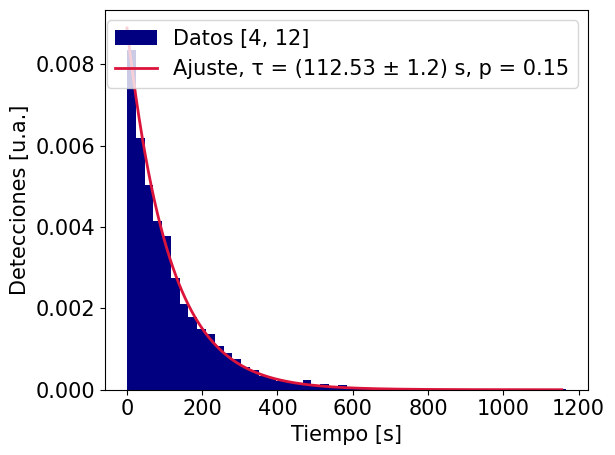

In [22]:
pair = [4,12]
df_pair = filtrar_coincidencias(filtered_df,[pair])

t_diffs = np.diff(df_pair.t)*1e-7
n,bins,_ = plt.hist(t_diffs,bins=50,density=True,color='navy',label=f'Datos {pair}')
x_hist = bins[:-1] + np.diff(bins)/2
y_hist = n
    
pars,cov = cf(exp_d,x_hist,y_hist,p0=[np.mean(t_diffs)])
x_adj = np.linspace(0,np.max(x_hist),1000)
y_adj = exp_d(x_adj,*pars)
exp_cdf = lambda x : 1 - np.exp(-x/pars[0])
pval_k = kstest(t_diffs,exp_cdf).pvalue
plt.plot(x_adj,y_adj,color='crimson',label=F'Ajuste, \u03C4 = ({np.round(pars[0],2)} \u00b1 {np.round(np.sqrt(cov[0,0]),2)}) s, p = {np.round(pval_k,2)}')
plt.legend()
plt.xlabel('Tiempo [s]')
plt.ylabel('Detecciones [u.a.]')

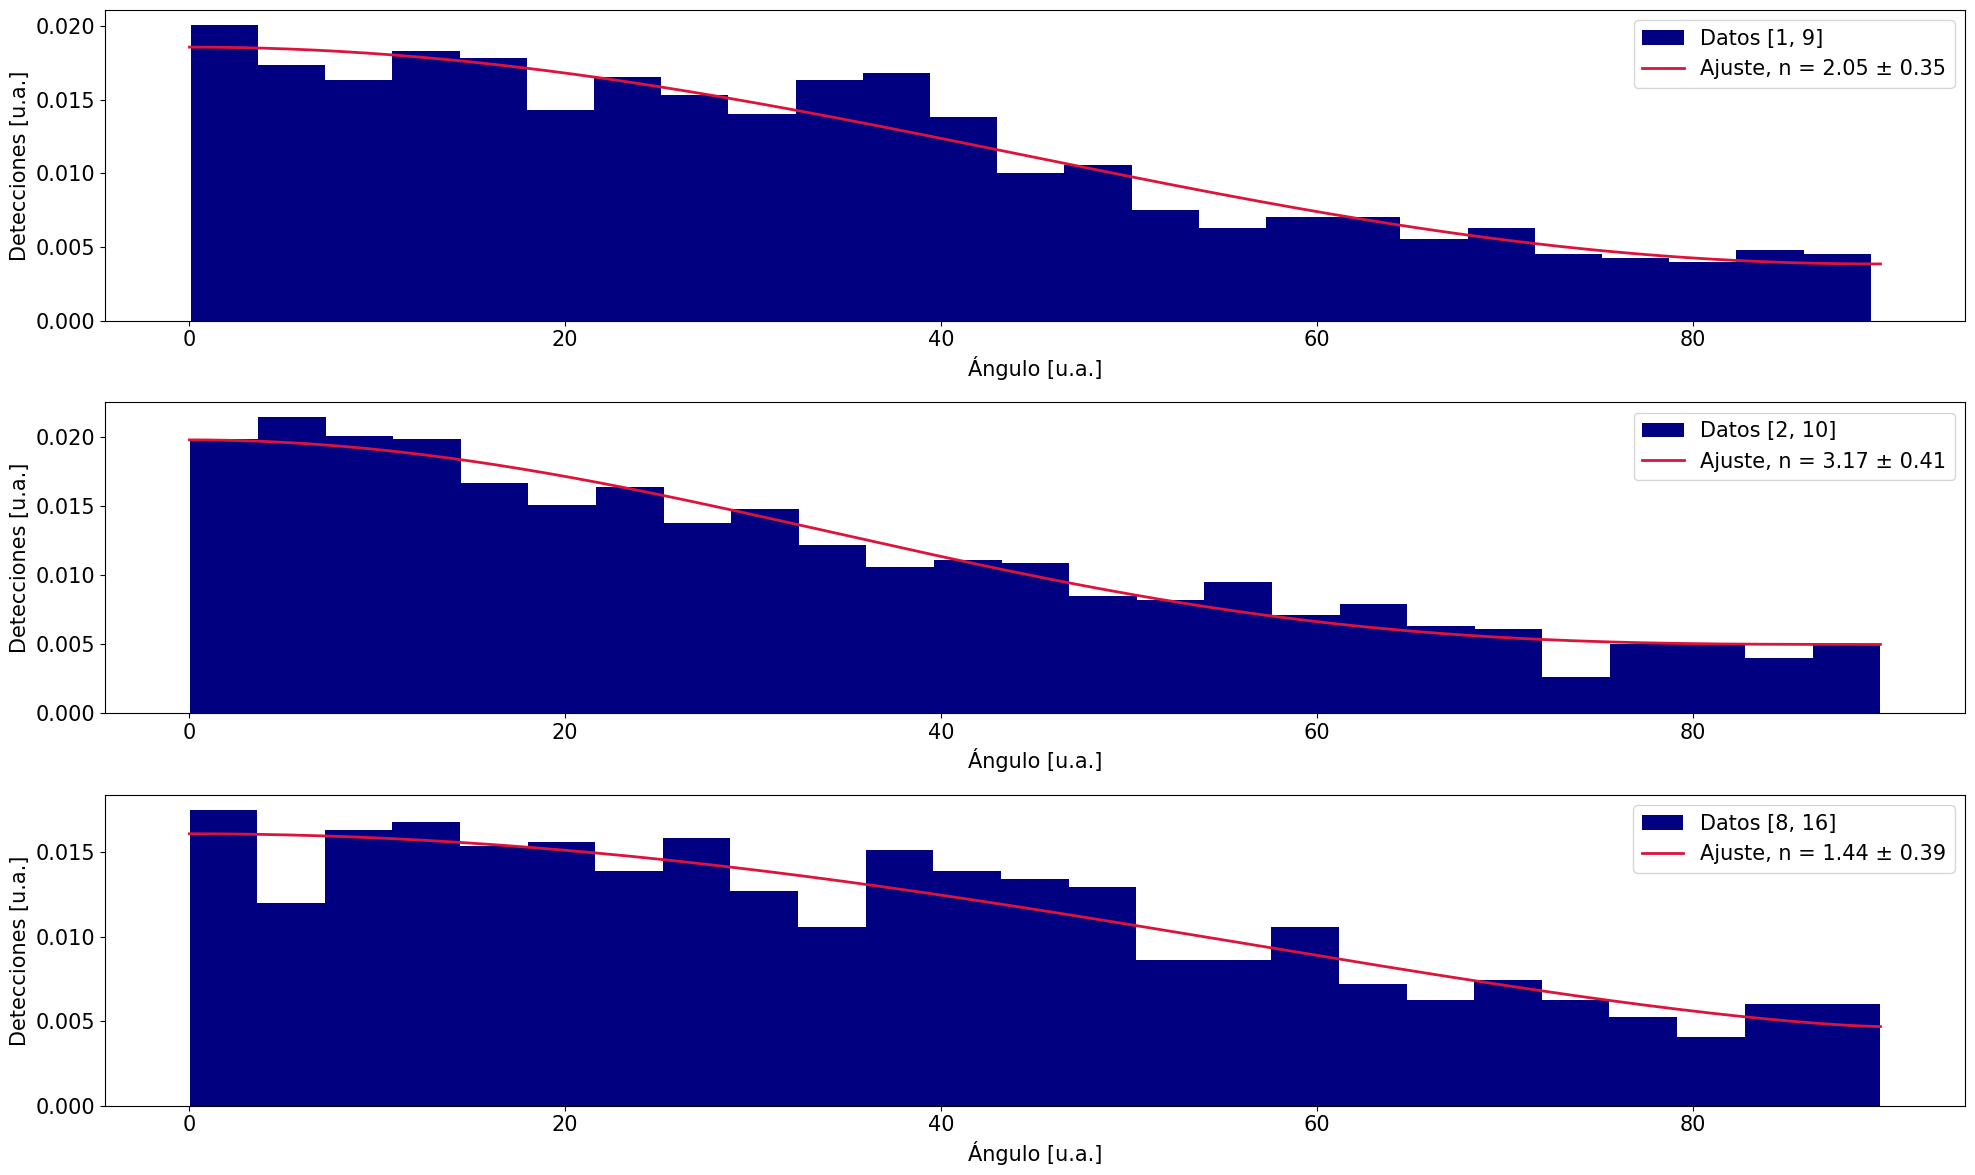

In [82]:
fig,axs = plt.subplots(3,1,figsize=(20,12),layout='tight')
axs = axs.flatten()
my_pairs = [[1,9],[2,10],[8,16]]
delta_cent = 18.7
center = (4879-lower_ang)*360/delta + np.array([-3,-2,4])*delta_cent
cos_n = lambda x,A,n,C : A*np.cos(np.radians(x))**n+C
for i in range(len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    angs_desc = (df_pair.ang - center[i]) % 360   
    angs_180 = angs_desc % 180
    angs_90 = np.where(angs_180 > 90,180-angs_180,angs_180)

    n,bins,_ = axs[i].hist(angs_90,bins=25,density=True,color='navy',label=f'Datos {pair}')

    x = bins[:-1] + np.diff(bins)/2
    y = n
    pars,cov = cf(cos_n,x,y,p0=[4/np.pi,2,0.005])
    n_m = pars[1]
    err_n_m = np.sqrt(cov[1,1])

    x_adj = np.linspace(0,90,200)
    y_adj = cos_n(x_adj,*pars)
    
    axs[i].plot(x_adj,y_adj,color='crimson',label=f'Ajuste, n = {np.round(n_m,2)} \u00b1 {np.round(err_n_m,2)}')
    
    
    axs[i].legend()
    axs[i].set_xlabel('Ángulo [u.a.]')
    axs[i].set_ylabel('Detecciones [u.a.]')